In [22]:
import equinox as eqx
import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jran
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
print(f"Pytorch version: {torch.__version__}")
from math import prod
print(f"JAX version: {jax.__version__}")
import optax
print(f"Optax version: {optax.__version__}")
import jax.tree_util as jtu
# import jax.numpy.linalg as jla
# from jax import jit, vmap
from jaxtyping import Array, Float, Int, PyTree # https://github.com/google/jaxtyping
from typing import Callable
from tqdm import tqdm
import matplotlib.pyplot as plt

Pytorch version: 2.12.0
JAX version: 0.10.0
Optax version: 0.2.8


In [23]:
import jax.nn.initializers as jinit

def make_linear(in_dim, out_dim, rng_key):
    layer = eqx.nn.Linear(in_dim, out_dim, key=rng_key)
    # in_axis=1 and out_axis=0 correctly targets Equinox's (out, in) weight shapes
    new_weight = jinit.lecun_normal(in_axis=1, out_axis=0)(rng_key, layer.weight.shape)
    new_bias = jnp.zeros_like(layer.bias)
    return eqx.tree_at(lambda l: (l.weight, l.bias), layer, (new_weight, new_bias))

def make_conv2d(in_ch, out_ch, kernel, rng_key):
    layer = eqx.nn.Conv2d(in_ch, out_ch, kernel_size=kernel, key=rng_key)
    # The trailing dimensions are bypassed, which correctly computes Conv fan_in
    new_weight = jinit.lecun_normal(in_axis=1, out_axis=0)(rng_key, layer.weight.shape)
    new_bias = jnp.zeros_like(layer.bias)
    return eqx.tree_at(lambda l: (l.weight, l.bias), layer, (new_weight, new_bias))

class NN_Build(eqx.Module):
    layers: list
    input_shape: tuple = eqx.field(static=True)
    output_dim: int = eqx.field(static=True)
    layer_dims: tuple = eqx.field(static=True)
    activation: Callable = eqx.field(static=True)
    key: jax.Array = eqx.field(static=True)

    def __init__(self, 
                 input_shape: tuple,
                 output_dim: int,
                 layer_dims: list,
                 activation: jax.nn = jnn.leaky_relu,
                 key: jax.random.PRNGKey=jax.random.PRNGKey(42),
                 ) :
        # PyTree structure for the layers of the neural network. The layers will be stored in a list, and each layer will be added according to the dimensions specified in layer_dims.
        # NamedTuple structure for the layers of the neural network.
        self.layers = []

        # layer_dimss is a list of tuples, where each tuple represents the size of the layer. 
        # For a linear layer, the tuple will have two elements (input_dim, output_dim). 
        # For a convolutional layer, the tuple will have three elements (input_channels, output_channels, kernel_size).
        self.layer_dims = tuple(tuple(x) if not isinstance(x, tuple) else x for x in layer_dims)
        if len(self.layer_dims) == 0:
            raise ValueError("At least one layer dimension must be specified in layer_dims.")
        self.activation = activation
        self.key = jax.random.PRNGKey(0) if key is None else key
        self.input_shape = input_shape
        self.output_dim = output_dim

        # Check if the layer dimensions are compatible with the input shape and output dimension. This function will raise an error if the dimensions do not match.
        self.check_layer_dims(self.input_shape, self.output_dim, self.layer_dims)
        print("Layer dimensions are compatible with input shape and output dimension.")

        # Model building loop according to the layer dimensions provided. The first layer is added separately to handle the input shape, and then the rest of the layers are added in a loop.
        keys = jax.random.split(self.key, len(self.layer_dims))
        if len(self.layer_dims) == 1:
            self._add_layer(self.layer_dims[0], None, self.layers, final_layer=True, key=keys[0])
        else:
            self._add_layer(self.layer_dims[0], None, self.layers, final_layer=False, key=keys[0])
            size_prev = self.layer_dims[0]
            for i, size_new in enumerate(self.layer_dims[1:-1]):
                self._add_layer(size_new, size_prev, self.layers, final_layer=False, key=keys[i+1])
                size_prev = size_new
            self._add_layer(self.layer_dims[-1], size_prev, self.layers, final_layer=True, key=keys[-1])
            size_prev = self.layer_dims[-1]


    def check_layer_dims(self,
                         input_shape: tuple,
                         output_dim: int,
                         layer_dims: list):
        # The function checks if the final data shape after passing through all layers matches the specified output dimension.
        # data_shape is the actual shape of the data as it passes through the layers of the neural network. 
        data_shape = input_shape
        for layer_dim in layer_dims:
            if len(layer_dim) not in [2, 3]:
                raise ValueError(f"Each layer dimension must be a tuple of length 2 (for linear layers) or 3 (for convolutional layers). Got {layer_dim}.")
            elif len(layer_dim) == 2:
                flattened_shape = prod(data_shape)
                if flattened_shape != layer_dim[0]:
                    raise ValueError(f"Expected input shape {data_shape} to be compatible with linear layer input dimension {layer_dim[0]}.")
                data_shape = (layer_dim[1],)
            elif len(layer_dim) == 3:
                if len(data_shape) == 3:
                    if data_shape[2] != layer_dim[0]:
                        raise ValueError(f"Expected input shape {data_shape} to be compatible with convolutional layer input channels {layer_dim[0]}.")
                    new_h = data_shape[0] - (layer_dim[2] - 1)
                    new_w = data_shape[1] - (layer_dim[2] - 1)
                    if new_h <= 0 or new_w <= 0:
                        raise ValueError(f"Kernel size {layer_dim[2]} is too large for input shape {data_shape}.")
                    data_shape = (new_h, new_w, layer_dim[1])
                elif len(data_shape) != 3:
                    raise ValueError(f"Cannot add a convolutional layer after a linear layer, got layer dimensions {layer_dim} after input shape {data_shape}.")
        if data_shape != (output_dim,):
            raise ValueError(f"Final layer shape {data_shape} does not match output dimension {output_dim}.")

    def _add_layer(self, 
                   layer_dim: tuple, 
                   prev_layer_dim: tuple, 
                   layers: list,
                   final_layer: bool = False,
                   key: jax.random.PRNGKey = None):
        # Special case for the first layer with no previous layer dimensions.
        if prev_layer_dim is None:
            if len(layer_dim) == 2:
                if len(self.input_shape) == 1:
                    if self.input_shape[0] != layer_dim[0]:
                        raise ValueError(
                            f"Expected input shape {self.input_shape} to match linear "
                            f"input dimension {layer_dim[0]}."
                        )
                    # layers.append(eqx.nn.Linear(layer_dim[0], layer_dim[1], key=key))
                    layers.append(make_linear(layer_dim[0], layer_dim[1], rng_key=key))

                elif len(self.input_shape) == 3:
                    if prod(self.input_shape) != layer_dim[0]:
                        raise ValueError(
                            f"Expected flattened input size {prod(self.input_shape)} to "
                            f"match linear input dimension {layer_dim[0]}."
                        )
                    layers.append(jnp.ravel)
                    # layers.append(eqx.nn.Linear(layer_dim[0], layer_dim[1], key=key))
                    layers.append(make_linear(layer_dim[0], layer_dim[1], rng_key=key))

            elif len(layer_dim) == 3: 
                if len(self.input_shape) != 3:
                    raise ValueError(f"Expected input shape {self.input_shape} to be compatible with convolutional layer input shape, got {layer_dim} after input shape {self.input_shape}.")
                if self.input_shape[2] != layer_dim[0]:
                    raise ValueError(f"Expected input shape {self.input_shape} to be compatible with convolutional layer input channels {layer_dim[0]}.")   
                elif len(self.input_shape) == 3:     
                    # layers.append(eqx.nn.Conv2d(layer_dim[0], layer_dim[1], kernel_size=layer_dim[2], key=key))
                    layers.append(make_conv2d(layer_dim[0], layer_dim[1], layer_dim[2], rng_key=key))
                elif len(self.input_shape) != 3:
                    raise ValueError(f"Cannot add a convolutional layer after a linear layer, got layer dimensions {layer_dim} after input shape {self.input_shape}.")
        # Adding rest of the layers according to the dimensions specified in layer_dim and prev_layer_dim. 
        # The function checks the dimensions and adds the appropriate layer (linear or convolutional) followed by the activation function.
        # No padding, stride of 1, and no dilation are assumed for convolutional layers.
        else:
            if len(layer_dim) == 2: 
                if len(prev_layer_dim) == 2:
                    if prev_layer_dim[1] != layer_dim[0]:
                        raise ValueError(f"Expected previous layer output dimension {prev_layer_dim[1]} to match linear input dimension {layer_dim[0]}.")
                    # layers.append(eqx.nn.Linear(layer_dim[0], layer_dim[1], key=key))
                    layers.append(make_linear(layer_dim[0], layer_dim[1], rng_key=key))
                elif len(prev_layer_dim) == 3:
                    layers.append(jnp.ravel)
                    # layers.append(eqx.nn.Linear(layer_dim[0], layer_dim[1], key=key))
                    layers.append(make_linear(layer_dim[0], layer_dim[1], rng_key=key))
            elif len(layer_dim) == 3:
                if len(prev_layer_dim) == 2:
                    raise ValueError(f"Cannot add a convolutional layer after a linear layer, got layer dimensions {layer_dim} after {prev_layer_dim}.")
                elif len(prev_layer_dim) == 3:
                    if prev_layer_dim[1] != layer_dim[0]:
                        raise ValueError(f"Expected previous layer output channels {prev_layer_dim[1]} to match linear input dimension {layer_dim[0]}.")
                    # layers.append(eqx.nn.Conv2d(layer_dim[0], layer_dim[1], kernel_size=layer_dim[2], key=key))
                    layers.append(make_conv2d(layer_dim[0], layer_dim[1], layer_dim[2], rng_key=key))
        # If this is not the final layer, we add the activation function.
        if not final_layer:
            layers.append(self.activation)

    def __call__(self, x):
        for l, layer in enumerate(self.layers):
            x = layer(x)
        return x
    


    

In [24]:
# @eqx.filter_jit
def mse_loss(model, x, y):
    preds = jax.vmap(model)(x)
    return jnp.mean((preds - y) ** 2)

# with np.load('../sbi_lens_sims/mpi_job_4483820_combined.npz') as data:
with np.load('../sbi_lens_sims/combined_overall.npz') as data:
    x = data['y']
    # Jax Conv layers expects data shape in (N, C, H, W) format, but the data is in (N, H, W, C) format. 
    # We need to transpose the data to match the expected input shape for the convolutional layers.
    x = jnp.transpose(x, (0, 3, 1, 2))  # NHWC -> NCHW 
    y = data['theta']
    # Remove any NaN data points
    nan_mask = jnp.isnan(x).reshape(x.shape[0], -1).any(axis=1)
    clean_indices = jnp.where(~nan_mask)[0]
    x = x[clean_indices]
    y = y[clean_indices]
    print("x", x.shape, "\n", "y", y.shape)



x (66295, 5, 60, 60) 
 y (66295, 6)


In [25]:
input_shape = (60,60,5)
output_dim = 6
layer_dims = ((5,3,11), (3,1,11), (1,1,11), (30*30, 100), (100, output_dim))
CNN = NN_Build(input_shape, output_dim, layer_dims)
print(CNN)

# Filter spec approach for partitioning model into params and static:
# 1. jtu.tree_map(lambda _: False, model) sets all non-layer fields to False
# 2. jtu.tree_map(eqx.is_array, model.layers) recursively checks each leaf in layers (arrays→True, modules→False)
# 3. eqx.tree_at replaces only the .layers subtree with the correct spec
# Result: non-layer fields are False, layer arrays are True for proper partitioning
filter_spec = eqx.tree_at(
    lambda m: m.layers,
    jtu.tree_map(lambda _: False, CNN),  # Step 1: ALL fields → False
    jtu.tree_map(eqx.is_array, CNN.layers)  # Step 2: layers → array mask
)

# params, static = eqx.partition(CNN, eqx.is_inexact_array)
params, static = eqx.partition(CNN, filter_spec)
print("params", params)
print("static", static)

Layer dimensions are compatible with input shape and output dimension.
NN_Build(
  layers=[
    Conv2d(
      num_spatial_dims=2,
      weight=f32[3,5,11,11],
      bias=f32[3,1,1],
      in_channels=5,
      out_channels=3,
      kernel_size=(11, 11),
      stride=(1, 1),
      padding=((0, 0), (0, 0)),
      dilation=(1, 1),
      groups=1,
      use_bias=True,
      padding_mode='ZEROS'
    ),
    <PjitFunction of <function leaky_relu at 0x1135c1da0>>,
    Conv2d(
      num_spatial_dims=2,
      weight=f32[1,3,11,11],
      bias=f32[1,1,1],
      in_channels=3,
      out_channels=1,
      kernel_size=(11, 11),
      stride=(1, 1),
      padding=((0, 0), (0, 0)),
      dilation=(1, 1),
      groups=1,
      use_bias=True,
      padding_mode='ZEROS'
    ),
    <PjitFunction of <function leaky_relu at 0x1135c1da0>>,
    Conv2d(
      num_spatial_dims=2,
      weight=f32[1,1,11,11],
      bias=f32[1,1,1],
      in_channels=1,
      out_channels=1,
      kernel_size=(11, 11),
      strid

/var/folders/yt/ybnb7bw10vj2y7213d6y2l_00000gn/T/ipykernel_5631/3801433590.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  CNN = NN_Build(input_shape, output_dim, layer_dims)


In [26]:
def train(
    model,
    loss: Callable,
    trainloader: torch.utils.data.DataLoader,
    testloader: torch.utils.data.DataLoader,
    optim: optax.GradientTransformation,
    steps: int,
    print_every: int,
) -> CNN:
    # Just like earlier: It only makes sense to train the arrays in our model,
    # so filter out everything else.
    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    filter_spec = eqx.tree_at(
    lambda m: m.layers,
    jtu.tree_map(lambda _: False, model),  # Step 1: ALL fields → False
    jtu.tree_map(eqx.is_array, model.layers)  # Step 2: layers → array mask
    )
    params, static = eqx.partition(model, filter_spec)
    opt_state = optim.init(params)

    # Always wrap everything -- computing gradients, running the optimiser, updating
    # the model -- into a single JIT region. This ensures things run as fast as
    # possible.
    @eqx.filter_jit
    def make_step(
        model,
        opt_state: PyTree,
        x: Float[Array, "batch 1 28 28"],
        y: Int[Array, " batch"],
        ):
        # filter_spec = eqx.tree_at(
        # lambda m: m.layers,
        # jtu.tree_map(lambda _: False, model),  # Step 1: ALL fields → False
        # jtu.tree_map(eqx.is_array, model.layers)  # Step 2: layers → array mask
        # )
        # params, static = eqx.partition(model, filter_spec)
        loss_value, grads = eqx.filter_value_and_grad(loss)(model, x, y)
        updates, opt_state = optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    def evaluate(model, loss, testloader: torch.utils.data.DataLoader):
        """This function evaluates the model on the test dataset,
        computing both the average loss and the average accuracy.
        """
        avg_loss = 0
        for x, y in testloader:
            x = x.numpy()
            y = y.numpy()
            # Note that all the JAX operations happen inside `loss` and `compute_accuracy`,
            # and both have JIT wrappers, so this is fast.
            avg_loss += loss(model, x, y)
        return avg_loss / len(testloader)

    # Loop over our training dataset as many times as we need.
    def infinite_trainloader():
        while True:
            yield from trainloader

    train_losses = []
    train_steps = []
    test_losses = []
    test_steps = []
    for step, (x, y) in tqdm(zip(range(steps), infinite_trainloader())):
        # PyTorch dataloaders give PyTorch tensors by default,
        # so convert them to NumPy arrays.
        x = x.numpy()
        y = y.numpy()
        model, opt_state, train_loss = make_step(model, opt_state, x, y)
        train_losses.append(train_loss)
        train_steps.append(step)
        if (step % print_every) == 0 or (step == steps - 1):
            test_loss = evaluate(model, loss, testloader)
            test_losses.append(test_loss)
            test_steps.append(step)
            print(f"Step {step:3d}| Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    print("Training completed.")

    return model, (train_steps, train_losses), (test_steps, test_losses)

In [28]:
# Hyperparameters
BATCH_SIZE = 512
LEARNING_RATE = 5e-6
STEPS = 1000
PRINT_EVERY = 100
TRAIN_TEST_SPLIT = 0.8

optim = optax.adamw(LEARNING_RATE)

# Create torch Datasets and corresponding train-test DataLoaders
x_tensor = torch.tensor(np.array(x), dtype=torch.float32)
y_tensor = torch.tensor(np.array(y), dtype=torch.float32)
dataset = TensorDataset(x_tensor, y_tensor)
train_size = int(TRAIN_TEST_SPLIT * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# Train Model
CNN, (train_steps, train_losses), (test_steps, test_losses) = train(CNN, mse_loss, train_loader, test_loader, optim, STEPS, PRINT_EVERY)

Train size: 53036, Test size: 13259


1it [00:03,  3.34s/it]

Step   0| Train Loss: 0.642333 | Test Loss: 0.617369


101it [00:39,  1.10s/it]

Step 100| Train Loss: 0.605524 | Test Loss: 0.604599


...

Step 800| Train Loss: 0.055277 | Test Loss: 0.054018


901it [05:56,  1.08s/it]

Step 900| Train Loss: 0.053601 | Test Loss: 0.049741


1000it [06:32,  2.55it/s]

Step 999| Train Loss: 0.047962 | Test Loss: 0.048053
Training completed.


(66295, 6) (66295, 6)


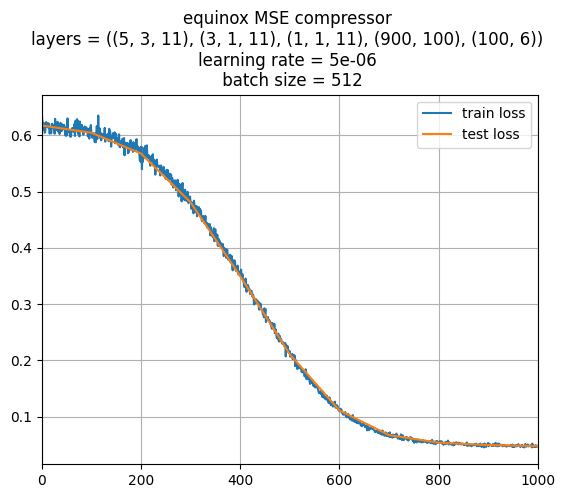

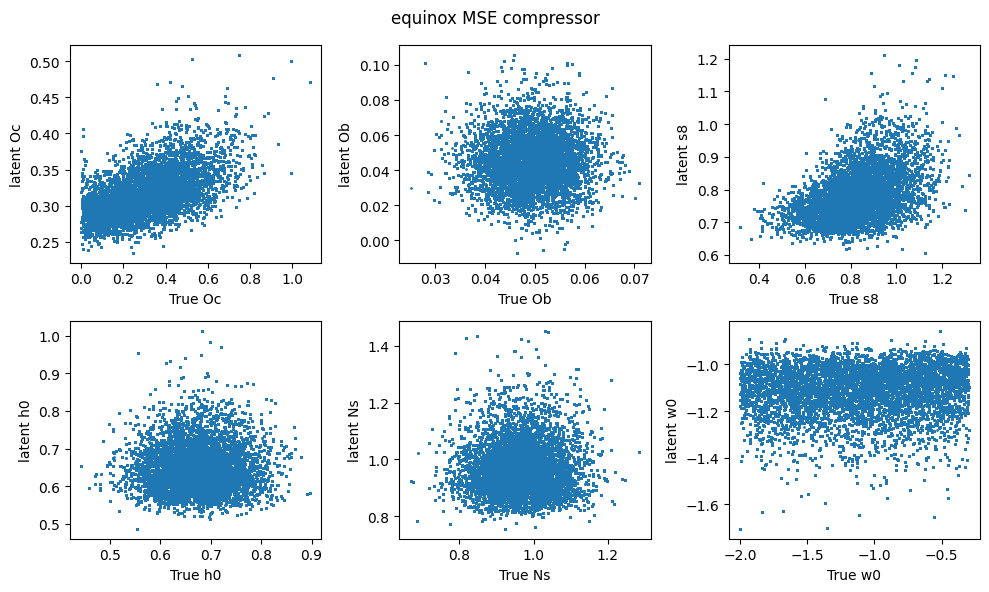

In [31]:
# Training loss time series
fig, ax = plt.subplots()
ax.plot(train_steps, train_losses, label='train loss')
ax.plot(test_steps, test_losses, label='test loss')
ax.set_xlim(0,STEPS)
plt.grid()
plt.legend()
plt.title("equinox MSE compressor")
plt.title(f"equinox MSE compressor \nlayers = {layer_dims} \nlearning rate = {LEARNING_RATE} \n batch size = {BATCH_SIZE}")
plt.savefig(f"eqx_MSE_loss_{STEPS}_steps.pdf")

# Truth vs Latent diagnostic scatter
gt = ground_truth = y
cp = compressed_data = jax.vmap(CNN)(x)
print(compressed_data.shape, y.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cp[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'latent {params[i]}')

plt.suptitle("equinox MSE compressor")
plt.tight_layout()
plt.savefig(f"eqx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()

(66295, 6) (66295, 6)


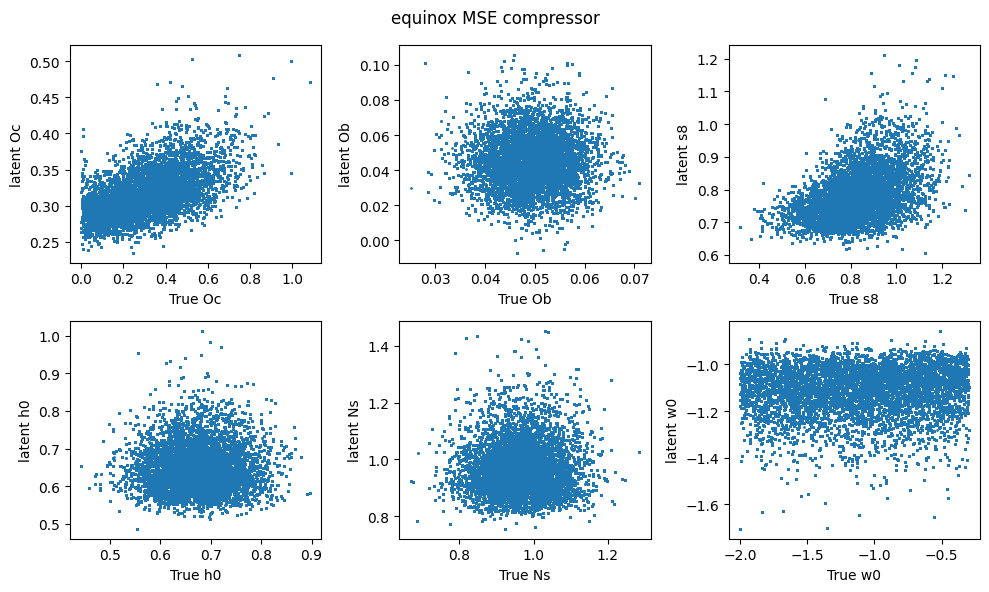

In [30]:
gt = ground_truth = y
cp = compressed_data = jax.vmap(CNN)(x)
print(compressed_data.shape, y.shape)

params = ['Oc','Ob','s8','h0','Ns','w0']
num_params = ground_truth.shape[1]

fig, axes = plt.subplots(2, 3, figsize=(10,6))
axes = axes.flatten()
for i in range(num_params):
    ax = axes[i]
    ax.scatter(gt[:,i], cp[:,i], s=1)
    ax.set_xlabel(f'True {params[i]}')
    ax.set_ylabel(f'latent {params[i]}')

plt.suptitle("equinox MSE compressor")
plt.tight_layout()
plt.savefig(f"eqx_MSE_scatter_{STEPS}_steps.pdf")
plt.show()

In [45]:

print(len(train_dataset))
print(compressed_data)
keys = jax.random.split(jax.random.PRNGKey(42), 4)
print(keys)

53036
[[ 0.30202872  0.04940303  0.828832    0.67340744  0.9656229  -1.1192445 ]
 [ 0.30188233  0.04930019  0.827853    0.6726023   0.9645815  -1.1180253 ]
 [ 0.3020338   0.0494047   0.82887083  0.6734421   0.96567607 -1.119309  ]
 ...
 [ 0.30196136  0.04936473  0.8284134   0.6730583   0.9651804  -1.1187303 ]
 [ 0.3016878   0.04917937  0.8265384   0.67150915  0.9631796  -1.1164073 ]
 [ 0.30178392  0.04924668  0.82718855  0.6720444   0.9638684  -1.1172122 ]]
[[1832780943  270669613]
 [  64467757 2916123636]
 [2465931498  255383827]
 [3134548294  894150801]]
